In [ ]:
from datetime import datetime

import pandas as pd
from numba.np.npdatetime_helpers import datetime_maximum
from statsmodels.sandbox.regression.example_kernridge import upper

from energymanagementrl.pv_prod_simulation.main import run_energy_production_prediction, analyze_production, WeatherType
from energymanagementrl.pv_prod_simulation.simulation import PanelModel, ArrayConfig, PlantConfig

In [533]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [534]:
df_0 = pd.read_csv('../data/complete_series.csv', parse_dates=['timestamp'], index_col='timestamp').drop(
    columns=['Unnamed: 0'])

In [535]:
start = df_0.index.min()
end = df_0.index.max()

Coordinates: 37.5625°N, 15.0°E
Elevation: 541.0 m asl
Timezone: b'Europe/Rome' b'CET'
Total AC energy: 18679.65 kWh
Max production: 5.76 kW at 2024-04-13 12:15:00
Production starts at: 2024-04-01 06:50:00, ends at: 2024-08-20 19:40:00


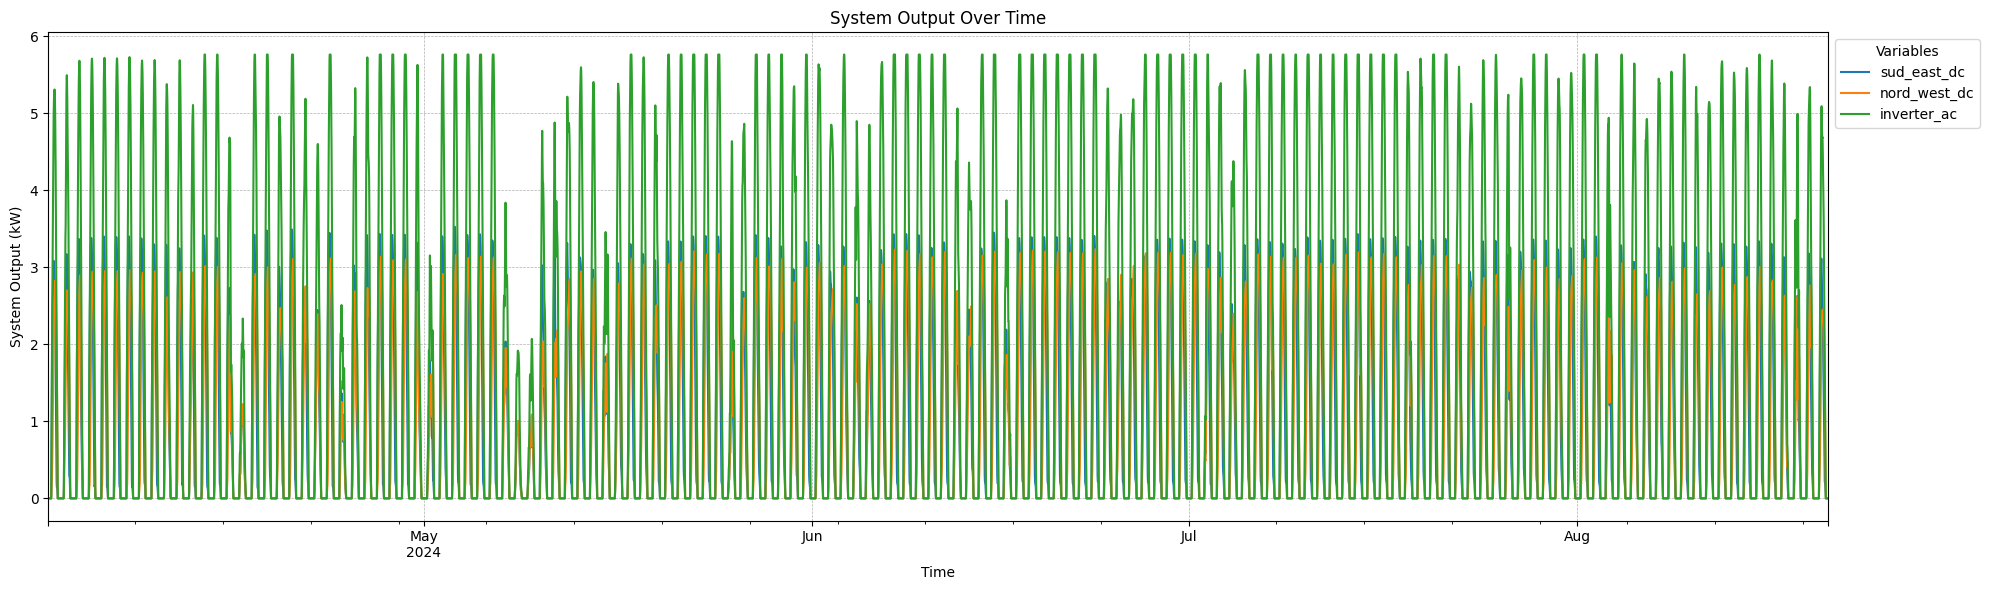

Total AC energy: 19853.38 kWh
Max production: 5.76 kW at 2024-04-29 12:45:00
Production starts at: 2024-04-01 06:50:00, ends at: 2024-08-19 19:40:00


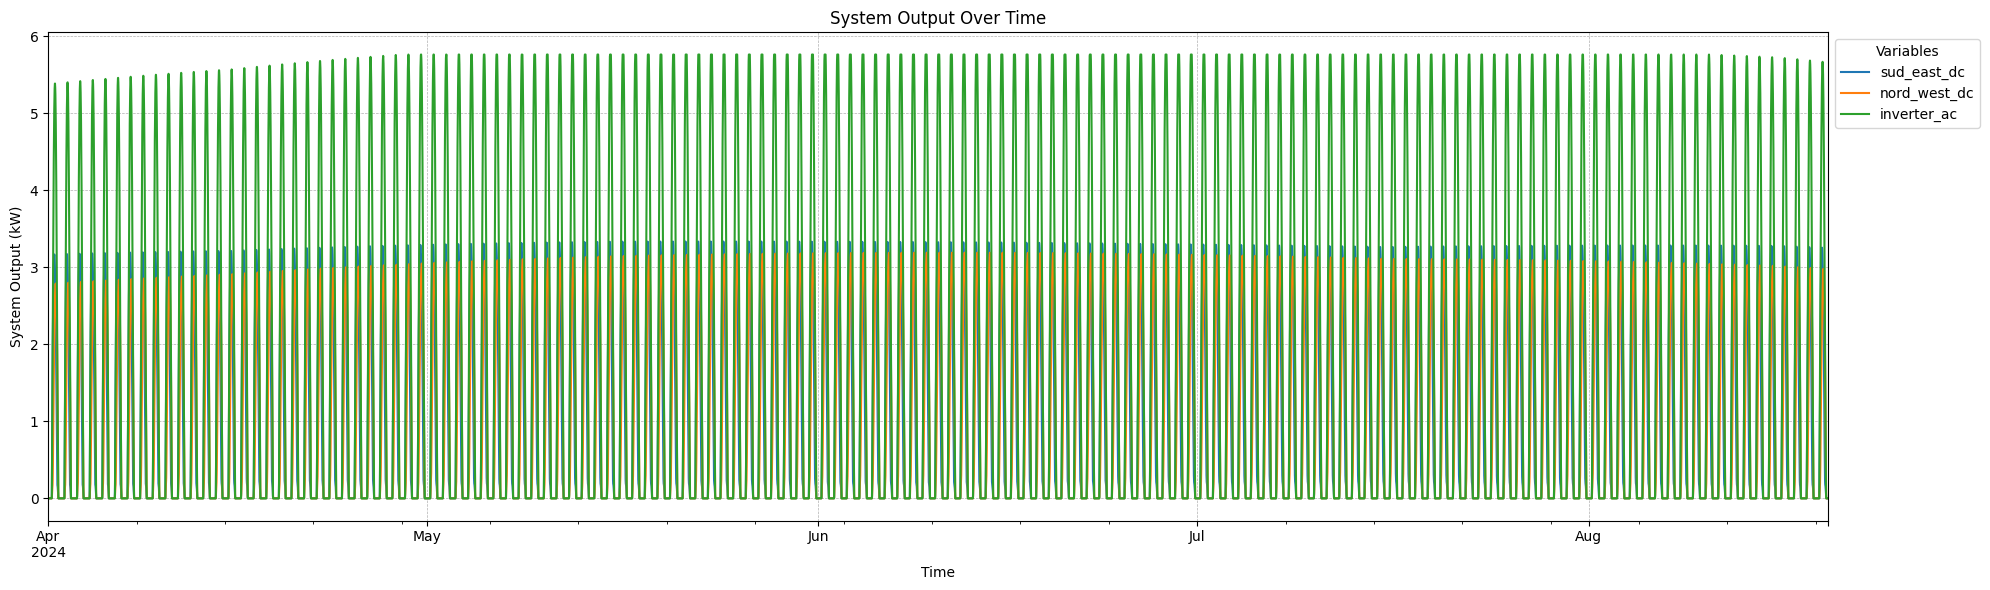

In [575]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=9, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=9, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
open_meteo_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
    WeatherType.open_meteo
)
open_meteo_production_df.index = open_meteo_production_df.index.tz_localize(None)
open_meteo_production_df = open_meteo_production_df.resample('5min').interpolate(method='linear')
analyze_production(open_meteo_production_df)
clear_sky_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
)
clear_sky_production_df.index = clear_sky_production_df.index.tz_localize(None)
clear_sky_production_df = clear_sky_production_df.resample('5min').interpolate(method='linear')
analyze_production(clear_sky_production_df)
clear_sky_production_df.rename({'inverter_ac': 'optimal_production_w'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'weather_dependent_production'}, axis=1, inplace=True)

<Axes: >

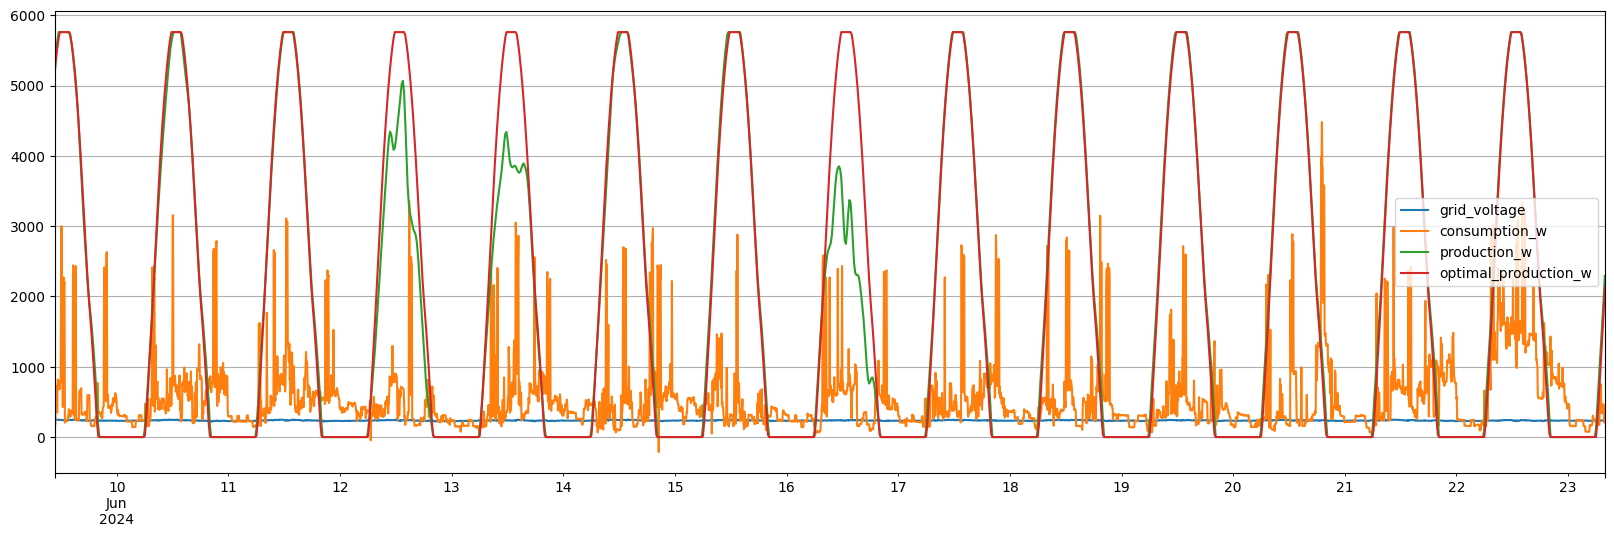

In [577]:

base=4000*5

df_0_ex=pd.concat([
    df_0,
    # open_meteo_production_df['weather_dependent_production'],
    clear_sky_production_df['optimal_production_w']*1000
],
          axis=1)

df_0_ex[base:base+4000].plot(figsize=(20, 6),grid=True)



In [582]:
df_0_ex.info()
df_0_ex.reset_index().rename({'index':'timestamp'},axis=1).to_csv('../data/complete_series.ex.csv',index=False)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40609 entries, 2024-04-01 00:00:00 to 2024-08-20 00:00:00
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   grid_voltage          40609 non-null  float64
 1   consumption_w         40609 non-null  float64
 2   production_w          40609 non-null  float64
 3   optimal_production_w  40609 non-null  float64
dtypes: float64(4)
memory usage: 2.6 MB


Coordinates 37.5625°N 15.0°E
Elevation 541.0 m asl
Timezone b'Europe/Rome' b'CET'
Timezone difference to GMT+0 3600 s


<Axes: xlabel='date'>

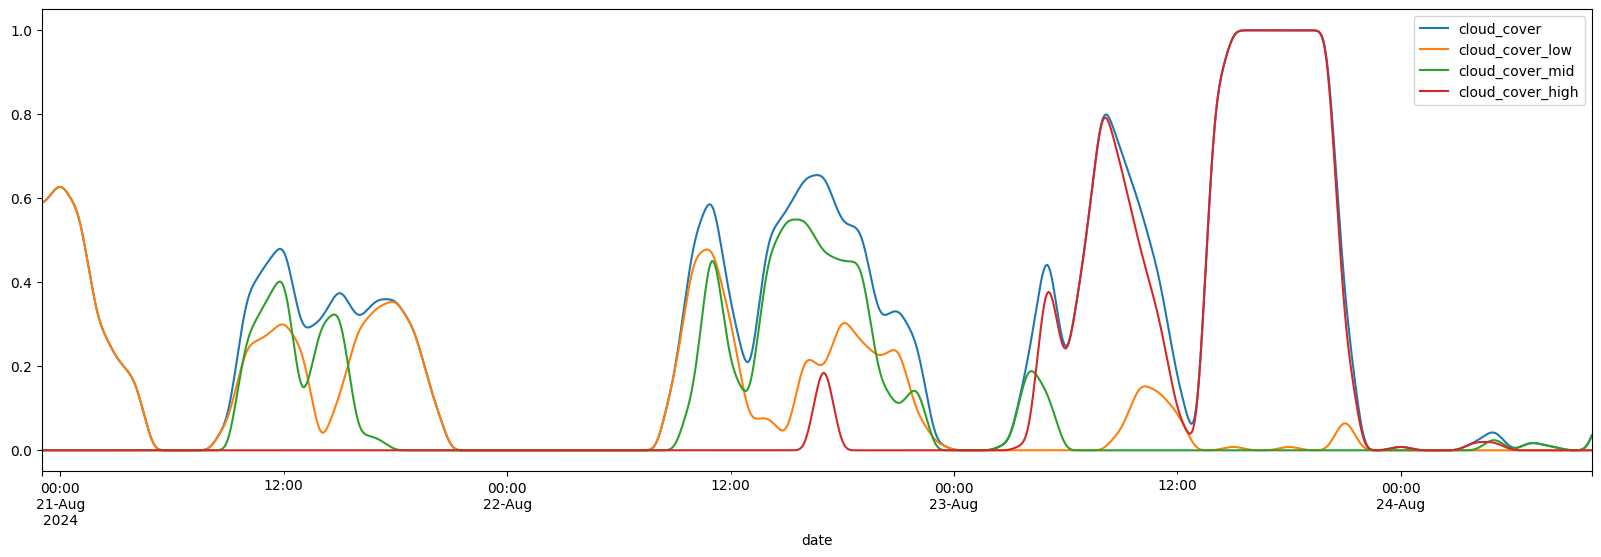

In [385]:
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry
from scipy.ndimage import gaussian_filter1d

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": start.strftime('%Y-%m-%d'),
    "end_date": end.strftime('%Y-%m-%d'),
    "timezone": "auto",
    "hourly": ["cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_cloud_cover = hourly.Variables(0).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(1).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(2).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"
)}
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high

hourly_dataframe = pd.DataFrame(data=hourly_data)
hourly_dataframe.set_index("date", inplace=True)
hourly_dataframe.index = pd.to_datetime(hourly_dataframe.index.astype('int') // 10 ** 9, unit='s')
hourly_dataframe_5min = hourly_dataframe.resample('5min').interpolate(method='linear')
sigma = 3  # Adjust sigma for smoothing level
hourly_dataframe_5min['cloud_cover'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover'].values, sigma)

hourly_dataframe_5min['cloud_cover_high'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_high'].values, sigma)
hourly_dataframe_5min['cloud_cover_low'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_low'].values, sigma)
hourly_dataframe_5min['cloud_cover_mid'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_mid'].values, sigma)
hourly_dataframe_5min = hourly_dataframe_5min / 100
hourly_dataframe_5min[:1000].plot(figsize=(20, 6))

In [386]:
clear_sky_production_df.rename({'inverter_ac': 'optimal_production'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'weather_dependent_production'}, axis=1, inplace=True)


In [387]:
plant_stat_history = pd.read_csv('../data/plant_stat_history.csv', )
plant_stat_history['startTime'] = pd.to_datetime(plant_stat_history['startTime'] + 3600, unit='s')
plant_stat_history.set_index('startTime', inplace=True)
plant_stat_history = plant_stat_history[['prodPower', 'SOC']][
    plant_stat_history.index > datetime.strptime('2024-08-21', '%Y-%m-%d')]
plant_stat_history.rename({'prodPower': 'real_production'}, axis=1, inplace=True)
plant_stat_history

,real_production,SOC
startTime,,
2024-08-21 00:05:00,0.0,77.0
2024-08-21 00:10:00,0.0,76.0
2024-08-21 00:15:00,0.0,76.0
2024-08-21 00:20:00,0.0,76.0
2024-08-21 00:25:00,0.0,76.0
...,...,...
2024-12-10 17:50:00,NaN,NaN
2024-12-10 17:55:00,NaN,NaN
2024-12-10 18:00:00,NaN,NaN


In [428]:
complete_data = pd.concat(
    [
        # open_meteo_production_df['weather_dependent_production'],
        # clear_sky_production_df['optimal_production'] * 1.05,
        hourly_dataframe_5min,
        plant_stat_history  #[plant_stat_history['SOC'] < 90]
    ],
    axis=1).dropna()
complete_data['real_production'] = complete_data['real_production'][complete_data['SOC'] < 90]
complete_data['real_production_smoothed'] = gaussian_filter1d(complete_data['real_production'], sigma=12, truncate=1)
complete_data['residuals'] = gaussian_filter1d(
    abs(complete_data['real_production'] - complete_data['real_production_smoothed']), sigma=12, truncate=1)
complete_data['residuals'].describe()

count    10555.000000
mean         0.107857
std          0.229182
min          0.000000
25%          0.000083
50%          0.001302
75%          0.109987
max          1.503775
Name: residuals, dtype: float64

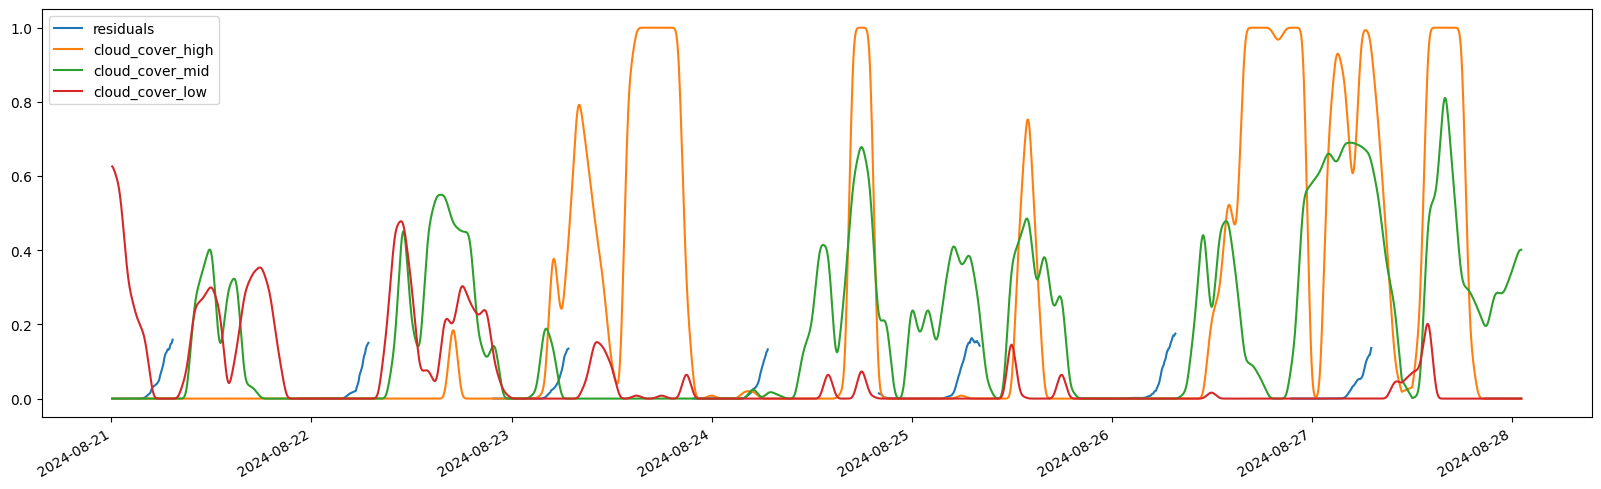

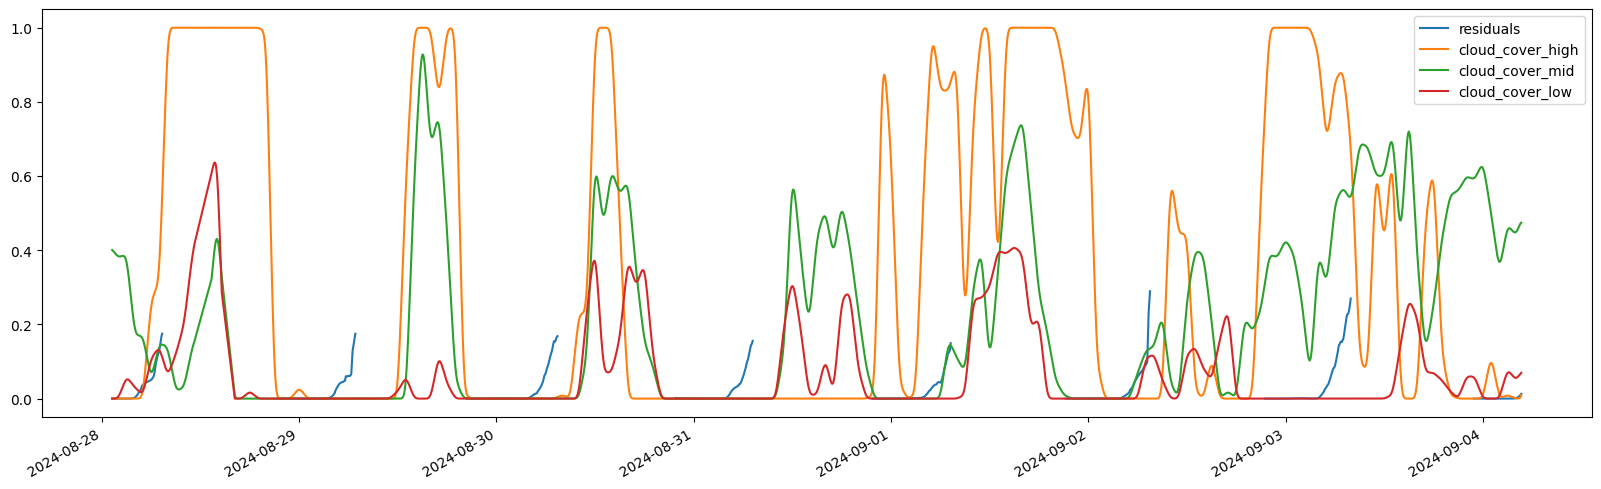

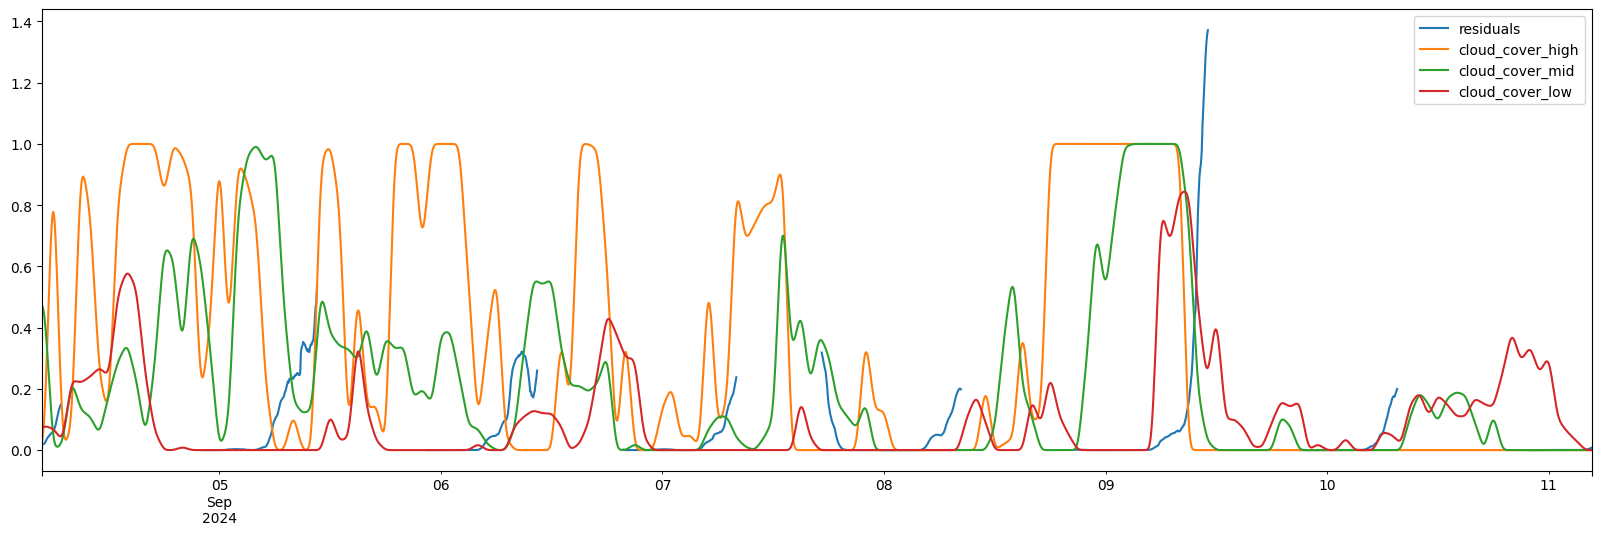

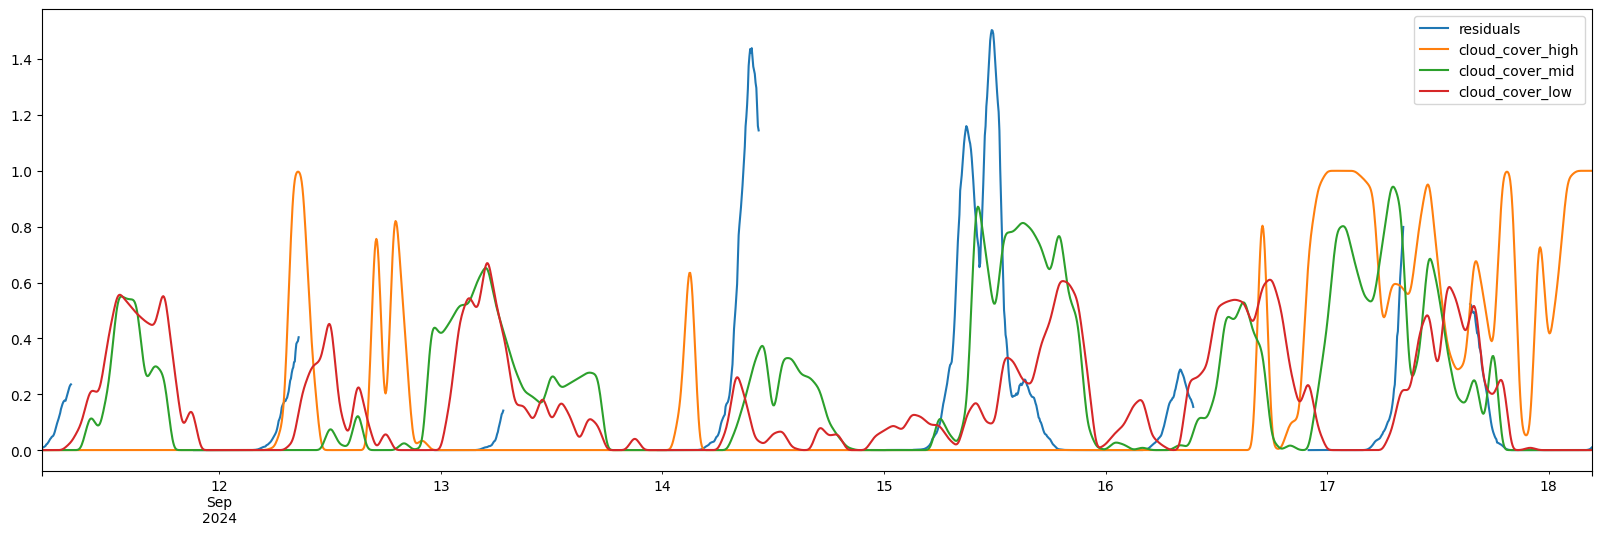

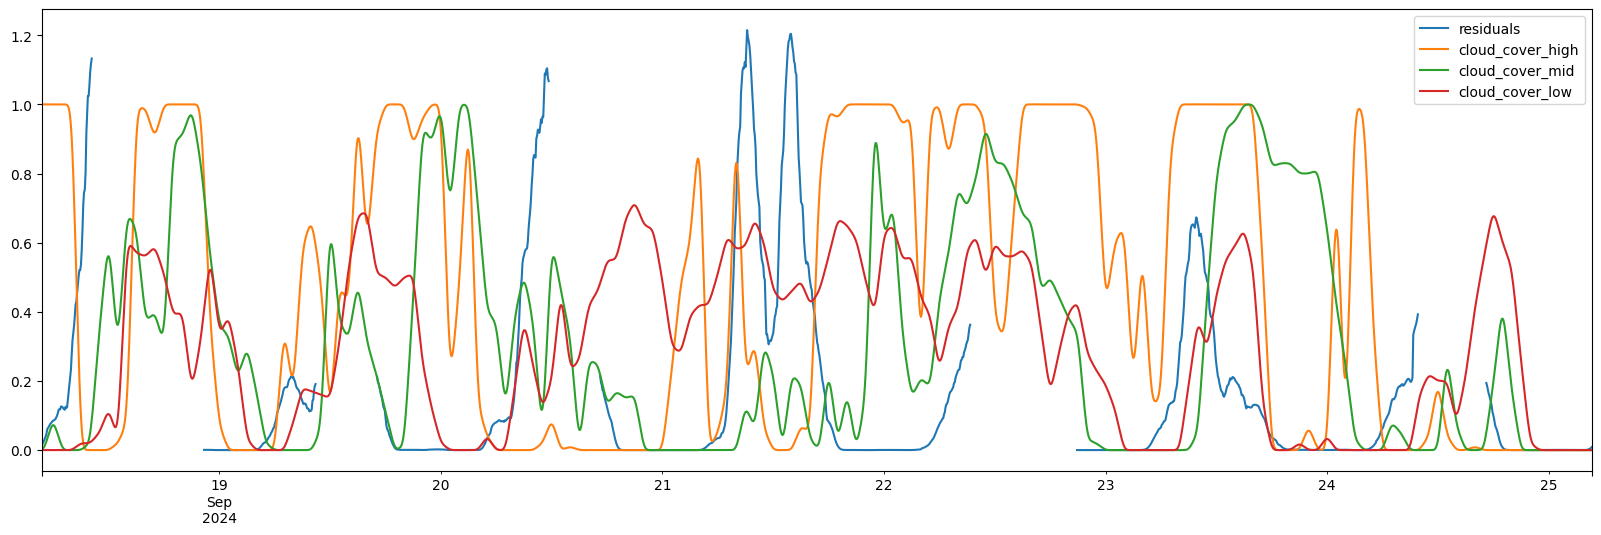

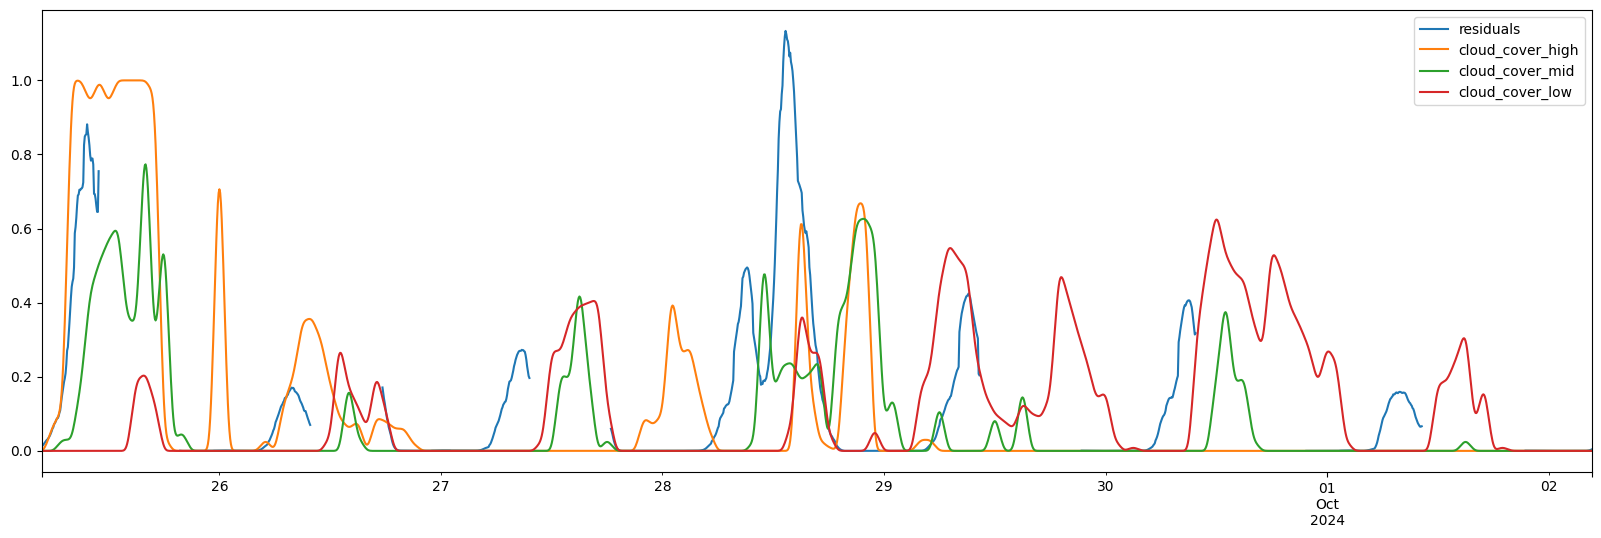

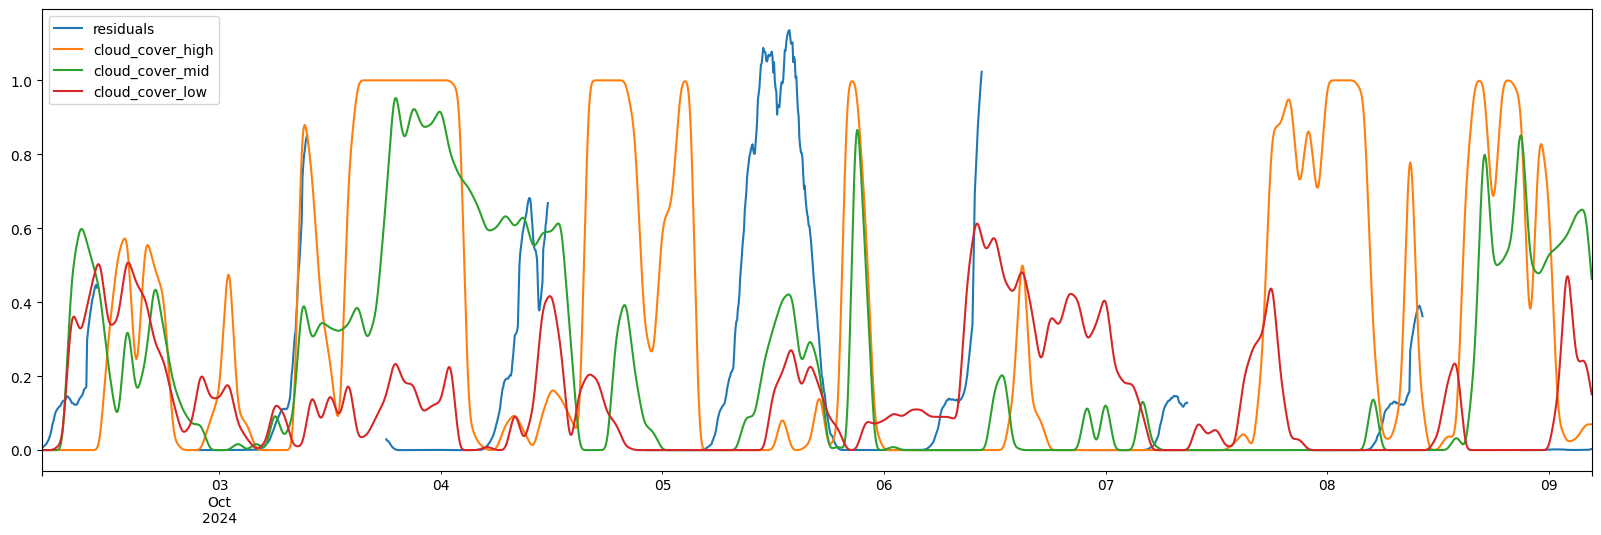

In [429]:
a = 288 * 7
for i in range(7):
    complete_data[[
        'residuals',
        'cloud_cover_high',
        'cloud_cover_mid',
        'cloud_cover_low',
        # 'real_production',
        # 'real_production_smoothed'
    ]][
    a * i:a * (i + 1)].plot(figsize=(20, 6))

In [502]:
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = complete_data[[
    'real_production_smoothed',
    'real_production',
    'residuals',
    'cloud_cover_high',
    'cloud_cover_mid',
    'cloud_cover_low',

]].dropna()
X = df[[
    'cloud_cover_low',
    'cloud_cover_mid',
    'cloud_cover_high',
    'real_production_smoothed'
]]
y = df['residuals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train a Gradient Boosted Tree model
model = LinearRegression()

model.fit(X_train, y_train)

# Evaluate the model
y_pred_test = model.predict(X_test)
print("Test RMSE:", mean_squared_error(y_test, y_pred_test, squared=False))

# Step 4: Predict baseline noise for the entire dataset
df['predicted_noise'] = model.predict(X)


Test RMSE: 0.14931091607458097


/home/emanuele/IdeaProjects/EnergyManagementRL/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [531]:
from scipy.optimize import curve_fit
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


# Custom function as specified
def custom_function(X, a1, b1, c1, a2, b2, c2, a3, b3, c3):
    x0, x1, x2, x3 = X  # Unpack independent variables
    return (
            x0 * (
            a1 / (1 + np.exp(-b1 * (x1 - c1))) +
            a2 / (1 + np.exp(-b2 * (x2 - c2))) +
            a3 / (1 + np.exp(-b3 * (x3 - c3)))
    )
    )


# Prepare the dataset
df = complete_data[[
    'real_production_smoothed',
    'real_production',
    'residuals',
    'cloud_cover_high',
    'cloud_cover_mid',
    'cloud_cover_low',
]].dropna()

X = df[[
    'real_production_smoothed',
    'cloud_cover_low',
    'cloud_cover_mid',
    'cloud_cover_high'
]].values.T  # Transpose for custom function
y = df['residuals'].values

X_train, X_test, y_train, y_test = train_test_split(X.T, y, test_size=0.2, random_state=42)

# Initial guess for the parameters (required by curve_fit)
initial_guess = [
    .7, 0.05, 50,
    .4, 0.05, 50,
    .15, 0.05, 50
]
# Define bounds for the parameters
lower_bounds = [
    0, 0, -100,  # Lower bounds for (a1, b1, c1)
    0, 0, -100,  # Lower bounds for (a2, b2, c2)
    0, 0, -100  # Lower bounds for (a3, b3, c3)
]
upper_bounds = [
    1, np.inf, 200,  # Upper bounds for (a1, b1, c1)
    1, np.inf, 200,  # Upper bounds for (a2, b2, c2)
    1, np.inf, 200  # Upper bounds for (a3, b3, c3)
]
# Fit the custom function
# Fit the custom function
popt, _ = curve_fit(
    custom_function,
    X_train.T,
    y_train,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    maxfev=1000000
)
# Predict on the test set
y_pred_test = custom_function(X_test.T, *popt)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred_test, squared=False)
print("Test RMSE:", rmse)

# Predict baseline noise for the entire dataset
df['predicted_noise'] = custom_function(X, *popt)

Test RMSE: 0.12920084586238076


/home/emanuele/IdeaProjects/EnergyManagementRL/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


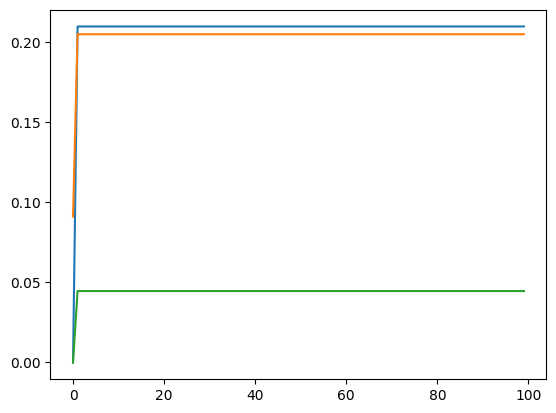

In [532]:
b = np.arange(0, 100, 1)
for i in range(3):
    a = popt[3 * i] / (1 + np.exp(-popt[3 * i + 1] * (b - popt[3 * i + 2])))
    plt.plot(b, a)

<Axes: >

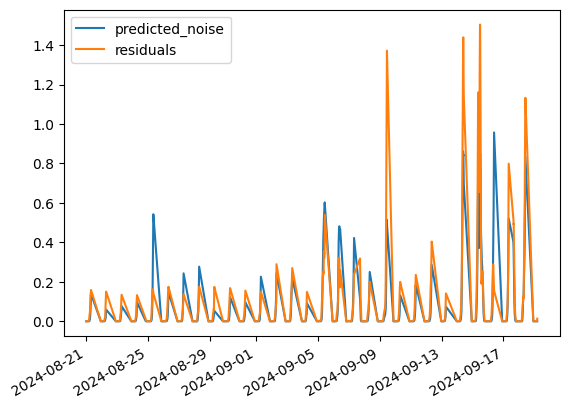

In [476]:
df[['predicted_noise', 'residuals']][:4000].plot()

(np.float64(0.015343443180115388), np.float64(0.13493030401335843))

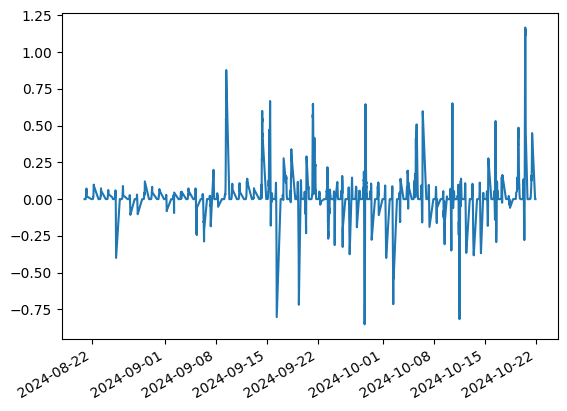

In [472]:
# Step 3: Fit a distribution to the residuals of the regression model
residuals_after_model = df['residuals'] - df['predicted_noise']
mean, std = norm.fit(residuals_after_model)
residuals_after_model.plot()
mean, std



In [420]:
# Step 4: Generate synthetic data
def generate_synthetic_production(forecasted, cloud_covariates):
    baseline_noise = model.predict(cloud_covariates)
    # random_noise = np.random.normal(mean, std, size=len(cloud_covariates))
    synthetic_noise = baseline_noise
    return forecasted + synthetic_noise


# Example: Generate synthetic data for the DataFrame
cloud_covariates = df[['cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'real_production_smoothed']]
df['synthetic_real_production'] = generate_synthetic_production(
    df['real_production_smoothed'], cloud_covariates
)

# Step 5: Validate synthetic data
print(df[['real_production', 'synthetic_real_production']].describe())

       real_production  synthetic_real_production
count     10555.000000               10555.000000
mean          0.545774                   0.660279
std           1.171031                   1.272741
min           0.000000                  -0.001949
25%           0.000000                   0.000470
50%           0.000000                   0.001810
75%           0.292000                   0.551417
max           7.170000                   5.755057


<Axes: >

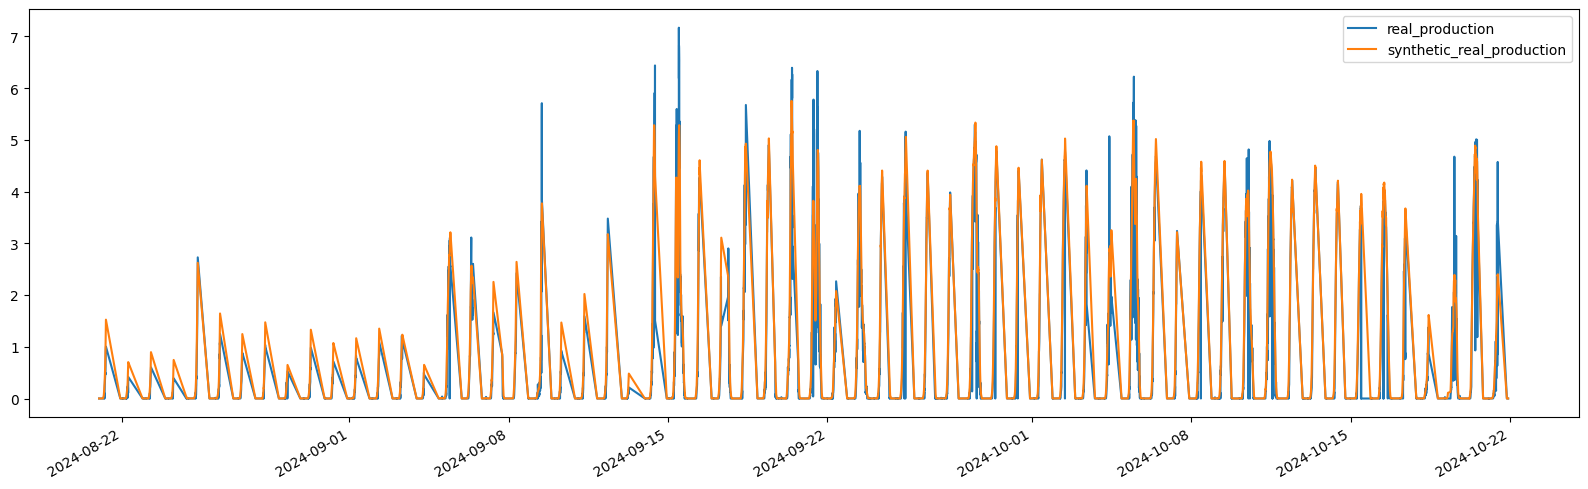

In [421]:
df[['real_production', 'synthetic_real_production']].plot(figsize=(20, 6))

In [433]:
y = residuals
x_0 = real_production_smoothed
x_1 = cloud_cover_low
x_2 = cloud_cover_mid
x_3 = cloud_cover_high
y = x_0 * (a_1 / (1 + np.exp(-b_1 * (x_1 - c_1)) + a_2 / (
        1 + np.exp(-b_2 * (x_2 - c_2)) + a_3 / (1 + np.exp(-b_3 * (x_3 - c_3)))

SyntaxError: incomplete input (2602592677.py, line 1)

In [620]:
np.random.normal(0,1)

-0.29662345271257684